<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/20B_NeuroFHIR_TRACE_REAL_Three_State_Gate_Calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 20B-REAL
## Outcome-Blind Three-State Reliability Gate Calibration and Held-Out Validation

This notebook replaces the earlier synthetic gate calibration with a **real ADNI1 reliability gate** built from:

- **75 same-day different-acquisition repeat pairs** (primary technical-repeatability reference)
- **15 same-source repeated-processing pairs** (secondary sensitivity arm)
- **258 real baseline→12-month longitudinal ADNI1 subjects**

### Core design

The gate is calibrated **without using pMCI/sMCI outcome labels**.

1. Split same-day acquisition repeats by subject into **development** and **held-out** sets.
2. Estimate biomarker-specific technical-noise envelopes from development repeats.
3. Confirm envelope coverage on held-out repeat pairs.
4. Lock those thresholds.
5. Apply them to real 12-month longitudinal changes.
6. Assign each biomarker evidence item one of three states:

- **TRUSTED** — observed longitudinal change exceeds the locked technical envelope and no hard QC/provenance concern is present.
- **CAUTION** — observed longitudinal change remains within the technical envelope or overall QC is partial, but no hard review condition is present.
- **REVIEW_REQUIRED** — a hard reliability concern is present, including excessive ICV drift or feature-relevant QC failure.

### Interpretation guardrail

The state refers to **reliability of the evidence of longitudinal change**, not diagnosis, clinical safety, or biological truth.

The gate is deliberately **outcome-blind** so later downstream experiments can test whether TRACE-aware evidence improves robustness without outcome leakage.


In [3]:

# Core imports
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 2027
rng = np.random.default_rng(SEED)

OUTDIR = Path("trace_20b_real_outputs")
OUTDIR.mkdir(exist_ok=True)

print("Output directory:", OUTDIR.resolve())


Output directory: /content/trace_20b_real_outputs



## 1. Upload the two participant-level CSV files using the Colab **Files** pane

Do **not** use `google.colab.files.upload()`.

In Colab:

1. Click the **folder icon** on the left.
2. Click **Upload**.
3. Upload:
   - `TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv`
   - `TRACE_ADNI1_repeat_pairs_REAL.csv`
4. Wait until both files are visible under `/content`.
5. Run the next cell.

These participant-level ADNI-derived files should remain local/private and should **not** be committed to GitHub.


In [4]:

# Robust loader: searches /content, current directory, and /mnt/data.

EXPECTED_LONG = "TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv"
EXPECTED_REP = "TRACE_ADNI1_repeat_pairs_REAL.csv"

SEARCH_DIRS = [Path("/content"), Path.cwd(), Path("/mnt/data")]

def find_file(expected_name):
    stem = Path(expected_name).stem
    suffix = Path(expected_name).suffix.lower()

    for d in SEARCH_DIRS:
        p = d / expected_name
        if p.exists():
            return p

    candidates = []
    for d in SEARCH_DIRS:
        if d.exists():
            candidates.extend(
                p for p in d.glob(f"{stem}*{suffix}") if p.is_file()
            )

    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]

LONGITUDINAL_PATH = find_file(EXPECTED_LONG)
REPEAT_PATH = find_file(EXPECTED_REP)

print("Visible CSV files:")
for d in SEARCH_DIRS:
    if d.exists():
        files = sorted(p.name for p in d.glob("*.csv"))
        if files:
            print(f"  {d}")
            for name in files:
                print("   -", name)

if LONGITUDINAL_PATH is None or REPEAT_PATH is None:
    missing = []
    if LONGITUDINAL_PATH is None:
        missing.append(EXPECTED_LONG)
    if REPEAT_PATH is None:
        missing.append(EXPECTED_REP)
    raise FileNotFoundError(
        "Missing required file(s): " + ", ".join(missing) +
        ". Upload them through the Colab left Files pane and rerun this cell."
    )

long_df = pd.read_csv(LONGITUDINAL_PATH)
rep_df = pd.read_csv(REPEAT_PATH)

print("\\nUsing longitudinal:", LONGITUDINAL_PATH)
print("Using repeats:", REPEAT_PATH)
print("Longitudinal shape:", long_df.shape)
print("Repeat-pair shape:", rep_df.shape)


Visible CSV files:
  /content
   - TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
   - TRACE_ADNI1_repeat_pairs_REAL.csv
  /content
   - TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
   - TRACE_ADNI1_repeat_pairs_REAL.csv
\nUsing longitudinal: /content/TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv
Using repeats: /content/TRACE_ADNI1_repeat_pairs_REAL.csv
Longitudinal shape: (258, 51)
Repeat-pair shape: (90, 51)


## 2. Cohort and schema audit

In [5]:

FEATURES = [
    "LHIPPOC",
    "RHIPPOC",
    "LENTORHIN",
    "RENTORHIN",
    "LMIDTEMP",
    "RMIDTEMP",
    "VENTRICLES",
    "ICV",
]

BIO_FEATURES = [f for f in FEATURES if f != "ICV"]

ACQ_TYPE = "SAME_DAY_DIFFERENT_ACQUISITION"
REPROC_TYPE = "SAME_SOURCE_REPROCESSING"

required_long = (
    ["RID", "LABEL", "BL_OVERALLQC", "M12_OVERALLQC",
     "BL_TEMPQC", "M12_TEMPQC", "BL_VENTQC", "M12_VENTQC"]
    + [f"BL_{f}" for f in FEATURES]
    + [f"M12_{f}" for f in FEATURES]
)

required_rep = (
    ["RID", "REPEAT_TYPE", "QC_1", "QC_2",
     "TEMPQC_1", "TEMPQC_2", "VENTQC_1", "VENTQC_2"]
    + [f"{f}_1" for f in FEATURES]
    + [f"{f}_2" for f in FEATURES]
    + [f"PCT_DIFF_{f}" for f in FEATURES]
)

missing_long = [c for c in required_long if c not in long_df.columns]
missing_rep = [c for c in required_rep if c not in rep_df.columns]

if missing_long:
    raise ValueError(f"Missing longitudinal columns: {missing_long}")
if missing_rep:
    raise ValueError(f"Missing repeat columns: {missing_rep}")

print("Longitudinal subjects:", long_df["RID"].nunique())
print(long_df["LABEL"].value_counts(dropna=False))

print("\nRepeat types:")
print(rep_df["REPEAT_TYPE"].value_counts(dropna=False))


Longitudinal subjects: 258
LABEL
pMCI    140
sMCI    118
Name: count, dtype: int64

Repeat types:
REPEAT_TYPE
SAME_DAY_DIFFERENT_ACQUISITION    75
SAME_SOURCE_REPROCESSING          15
Name: count, dtype: int64



## 3. Subject-level development / held-out split of same-day repeats

The split occurs by **RID**, not by pair row, to prevent the same participant from appearing in both calibration and held-out reliability validation.

No pMCI/sMCI label is used.


In [6]:

acq = rep_df.loc[rep_df["REPEAT_TYPE"] == ACQ_TYPE].copy()
reproc = rep_df.loc[rep_df["REPEAT_TYPE"] == REPROC_TYPE].copy()

unique_rids = np.array(sorted(acq["RID"].dropna().unique()))
rng.shuffle(unique_rids)

n_dev_subjects = int(np.floor(0.70 * len(unique_rids)))
dev_rids = set(unique_rids[:n_dev_subjects])
heldout_rids = set(unique_rids[n_dev_subjects:])

rep_dev = acq.loc[acq["RID"].isin(dev_rids)].copy()
rep_heldout = acq.loc[acq["RID"].isin(heldout_rids)].copy()

print("Same-day acquisition subjects:", len(unique_rids))
print("Development subjects:", len(dev_rids), "| pairs:", len(rep_dev))
print("Held-out subjects:", len(heldout_rids), "| pairs:", len(rep_heldout))

assert dev_rids.isdisjoint(heldout_rids)


Same-day acquisition subjects: 60
Development subjects: 42 | pairs: 56
Held-out subjects: 18 | pairs: 19



## 4. Calibrate biomarker-specific technical envelopes on development repeats

The primary threshold is the **95th percentile** of absolute same-day percent disagreement.

For sensitivity analysis we also retain the 90th and 99th percentiles.

These are empirical technical-noise envelopes, not clinical cutoffs.


In [7]:

threshold_rows = []

for f in FEATURES:
    vals = pd.to_numeric(rep_dev[f"PCT_DIFF_{f}"], errors="coerce").dropna().to_numpy()
    threshold_rows.append({
        "feature": f,
        "n_dev_pairs": len(vals),
        "q50_pct": float(np.percentile(vals, 50)),
        "q75_pct": float(np.percentile(vals, 75)),
        "q90_pct": float(np.percentile(vals, 90)),
        "q95_pct": float(np.percentile(vals, 95)),
        "q99_pct": float(np.percentile(vals, 99)),
    })

thresholds = pd.DataFrame(threshold_rows)
thresholds


,feature,n_dev_pairs,q50_pct,q75_pct,q90_pct,q95_pct,q99_pct
0,LHIPPOC,56,2.851275,4.948811,7.500928,8.523330,11.592307
1,RHIPPOC,56,2.092390,3.689865,7.235930,7.942049,8.662877
2,LENTORHIN,56,15.116902,20.485571,29.360964,42.186265,54.091105
3,RENTORHIN,56,15.652715,30.795872,47.577536,58.301455,63.209624
4,LMIDTEMP,56,2.652731,4.892647,7.199013,8.810247,27.377206
5,RMIDTEMP,56,3.131465,5.463952,10.282098,13.143210,17.864278
6,VENTRICLES,56,0.476846,0.761088,1.114651,1.186811,2.002128
7,ICV,56,0.153958,0.248722,0.358409,0.697830,0.910241


## 5. Held-out validation of the locked technical envelopes

In [8]:

coverage_rows = []

for f in FEATURES:
    vals = pd.to_numeric(rep_heldout[f"PCT_DIFF_{f}"], errors="coerce").dropna()
    row = thresholds.loc[thresholds["feature"] == f].iloc[0]

    for q in [90, 95, 99]:
        thr = row[f"q{q}_pct"]
        coverage_rows.append({
            "feature": f,
            "threshold": f"q{q}",
            "threshold_pct": thr,
            "n_heldout_pairs": int(len(vals)),
            "heldout_coverage_pct": 100.0 * float((vals <= thr).mean()) if len(vals) else np.nan,
            "heldout_exceedance_pct": 100.0 * float((vals > thr).mean()) if len(vals) else np.nan,
        })

coverage = pd.DataFrame(coverage_rows)
coverage_pivot = coverage.pivot(
    index="feature",
    columns="threshold",
    values="heldout_coverage_pct"
).reset_index()

coverage_pivot


threshold,feature,q90,q95,q99
0,ICV,84.210526,94.736842,94.736842
1,LENTORHIN,78.947368,89.473684,94.736842
2,LHIPPOC,68.421053,73.684211,84.210526
3,LMIDTEMP,63.157895,63.157895,100.000000
4,RENTORHIN,100.000000,100.000000,100.000000
5,RHIPPOC,73.684211,78.947368,78.947368
6,RMIDTEMP,89.473684,94.736842,94.736842
7,VENTRICLES,73.684211,78.947368,78.947368



## 6. Secondary sensitivity: repeated-processing records

These records are not pooled into calibration. They are used to test whether the acquisition-derived envelopes also characterize a different technical mechanism.


In [9]:

reproc_rows = []

for f in FEATURES:
    vals = pd.to_numeric(reproc[f"PCT_DIFF_{f}"], errors="coerce").dropna()
    thr95 = float(thresholds.loc[thresholds["feature"] == f, "q95_pct"].iloc[0])

    reproc_rows.append({
        "feature": f,
        "n_reprocessing_pairs": int(len(vals)),
        "median_reprocessing_pct": float(vals.median()) if len(vals) else np.nan,
        "q95_acquisition_threshold_pct": thr95,
        "reprocessing_coverage_under_acq_q95_pct":
            100.0 * float((vals <= thr95).mean()) if len(vals) else np.nan,
    })

reproc_sensitivity = pd.DataFrame(reproc_rows)
reproc_sensitivity


,feature,n_reprocessing_pairs,median_reprocessing_pct,q95_acquisition_threshold_pct,reprocessing_coverage_under_acq_q95_pct
0,LHIPPOC,15,2.380634,8.523330,100.000000
1,RHIPPOC,15,1.181628,7.942049,100.000000
2,LENTORHIN,15,8.054196,42.186265,93.333333
3,RENTORHIN,15,10.609586,58.301455,100.000000
4,LMIDTEMP,15,1.595379,8.810247,100.000000
5,RMIDTEMP,15,1.708787,13.143210,100.000000
6,VENTRICLES,15,0.562217,1.186811,86.666667
7,ICV,15,0.580549,0.697830,86.666667



## 7. Compute real longitudinal percent changes

For each feature:

\[
\text{absolute longitudinal % change}
=
100 \times \frac{|M12-BL|}{|BL|}
\]

The locked development-repeat Q95 threshold is then applied without outcome-based tuning.


In [10]:

gate_df = long_df.copy()

for f in FEATURES:
    bl = pd.to_numeric(gate_df[f"BL_{f}"], errors="coerce")
    m12 = pd.to_numeric(gate_df[f"M12_{f}"], errors="coerce")

    pct = 100.0 * np.abs(m12 - bl) / np.abs(bl)
    pct = pct.replace([np.inf, -np.inf], np.nan)

    thr95 = float(thresholds.loc[thresholds["feature"] == f, "q95_pct"].iloc[0])

    gate_df[f"{f}_ABS_LONG_PCT"] = pct
    gate_df[f"{f}_TECH_Q95"] = thr95
    gate_df[f"{f}_SIGNAL_TO_TECH"] = pct / thr95
    gate_df[f"{f}_EXCEEDS_TECH_Q95"] = pct > thr95

gate_df[[
    "RID", "LABEL"
] + [f"{f}_SIGNAL_TO_TECH" for f in BIO_FEATURES]].head()


,RID,LABEL,LHIPPOC_SIGNAL_TO_TECH,RHIPPOC_SIGNAL_TO_TECH,LENTORHIN_SIGNAL_TO_TECH,RENTORHIN_SIGNAL_TO_TECH,LMIDTEMP_SIGNAL_TO_TECH,RMIDTEMP_SIGNAL_TO_TECH,VENTRICLES_SIGNAL_TO_TECH
0,4,sMCI,0.754961,0.721813,0.497973,0.020082,0.194563,0.001364,2.679519
1,6,sMCI,0.361872,0.488105,0.369221,0.037413,0.357439,0.181512,1.875520
2,30,pMCI,0.630639,0.589659,0.028499,0.038116,1.168633,0.063878,4.255080
3,33,sMCI,0.872704,0.992784,0.397266,0.057774,0.053849,0.255803,7.171613
4,41,pMCI,0.246460,0.419707,1.016459,0.561531,0.537718,0.105964,7.335186



## 8. Define hard reliability concerns

The gate uses only interpretable technical/QC information.

### Global hard concern
**ICV drift above the locked same-day Q95 envelope.**

Adult intracranial volume should be approximately stable over 12 months. Excessive ICV drift therefore acts as a global segmentation/provenance instability marker.

### Feature-relevant hard QC concern
- `LMIDTEMP` / `RMIDTEMP`: temporal-lobe QC failure at either visit.
- `VENTRICLES`: ventricular QC failure at either visit.

For hippocampal and entorhinal measures, the available QC fields do not provide an equally specific feature mapping, so the notebook does not invent one.

### Overall partial QC
Overall `Partial` does **not** automatically force review. It prevents a feature from being labeled TRUSTED and therefore yields CAUTION unless a hard review condition exists.


In [11]:

# Global ICV technical-instability flag
gate_df["ICV_HARD_REVIEW"] = gate_df["ICV_EXCEEDS_TECH_Q95"].fillna(True)

# Overall quality sufficient for TRUSTED only when both visits are Pass
gate_df["OVERALL_QC_BOTH_PASS"] = (
    gate_df["BL_OVERALLQC"].astype(str).eq("Pass")
    & gate_df["M12_OVERALLQC"].astype(str).eq("Pass")
)

# Region-specific QC flags
gate_df["TEMP_HARD_REVIEW"] = (
    gate_df["BL_TEMPQC"].astype(str).eq("Fail")
    | gate_df["M12_TEMPQC"].astype(str).eq("Fail")
)

gate_df["VENT_HARD_REVIEW"] = (
    gate_df["BL_VENTQC"].astype(str).eq("Fail")
    | gate_df["M12_VENTQC"].astype(str).eq("Fail")
)

print("Global ICV hard review:", int(gate_df["ICV_HARD_REVIEW"].sum()), "/", len(gate_df))
print("Temporal QC hard review:", int(gate_df["TEMP_HARD_REVIEW"].sum()), "/", len(gate_df))
print("Ventricle QC hard review:", int(gate_df["VENT_HARD_REVIEW"].sum()), "/", len(gate_df))
print("Both visits overall Pass:", int(gate_df["OVERALL_QC_BOTH_PASS"].sum()), "/", len(gate_df))


Global ICV hard review: 81 / 258
Temporal QC hard review: 81 / 258
Ventricle QC hard review: 2 / 258
Both visits overall Pass: 136 / 258



## 9. Locked feature-level three-state gate

For each longitudinal biomarker evidence item:

### REVIEW_REQUIRED
- global ICV technical-instability flag, **or**
- feature-relevant hard QC failure.

### TRUSTED
- no hard review condition,
- overall QC is `Pass` at both visits,
- observed longitudinal change exceeds that feature's locked development-repeat Q95 envelope.

### CAUTION
Everything else.

This design deliberately separates:

- **technical reliability concern** → REVIEW_REQUIRED
- **change not clearly distinguishable from technical variability / partial QC** → CAUTION
- **change clearly exceeds technical variability under clean QC** → TRUSTED


In [12]:

def feature_hard_review(df, feature):
    hard = df["ICV_HARD_REVIEW"].copy()

    if feature in {"LMIDTEMP", "RMIDTEMP"}:
        hard = hard | df["TEMP_HARD_REVIEW"]

    if feature == "VENTRICLES":
        hard = hard | df["VENT_HARD_REVIEW"]

    return hard

for f in BIO_FEATURES:
    hard = feature_hard_review(gate_df, f)
    exceeds = gate_df[f"{f}_EXCEEDS_TECH_Q95"].fillna(False)

    state = np.where(
        hard,
        "REVIEW_REQUIRED",
        np.where(
            gate_df["OVERALL_QC_BOTH_PASS"] & exceeds,
            "TRUSTED",
            "CAUTION"
        )
    )

    gate_df[f"{f}_TRACE_STATE"] = state

state_rows = []
for f in BIO_FEATURES:
    counts = gate_df[f"{f}_TRACE_STATE"].value_counts()
    for state in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]:
        state_rows.append({
            "feature": f,
            "state": state,
            "n": int(counts.get(state, 0)),
            "pct": 100.0 * float(counts.get(state, 0)) / len(gate_df),
        })

feature_state_summary = pd.DataFrame(state_rows)
feature_state_summary.pivot(index="feature", columns="state", values="pct").round(1)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
feature,,,
LENTORHIN,66.3,31.4,2.3
LHIPPOC,64.0,31.4,4.7
LMIDTEMP,42.2,51.9,5.8
RENTORHIN,68.6,31.4,0.0
RHIPPOC,62.4,31.4,6.2
RMIDTEMP,47.7,51.9,0.4
VENTRICLES,34.1,32.2,33.7



## 10. Subject-level evidence-package summary

A subject-level package state is needed for downstream A/B/C experiments.

The primary deterministic rule is:

- **REVIEW_REQUIRED** if the global ICV hard-review flag is present **or** at least two biological evidence items require review.
- **TRUSTED** if there is no review condition and at least **4 of 7** biological evidence items are TRUSTED.
- **CAUTION** otherwise.

The `4 of 7` rule is a simple majority and is **not learned from outcomes**. A sensitivity analysis with 3/7 and 5/7 is included below.


In [13]:

state_cols = [f"{f}_TRACE_STATE" for f in BIO_FEATURES]

gate_df["N_TRUSTED"] = (gate_df[state_cols] == "TRUSTED").sum(axis=1)
gate_df["N_CAUTION"] = (gate_df[state_cols] == "CAUTION").sum(axis=1)
gate_df["N_REVIEW"] = (gate_df[state_cols] == "REVIEW_REQUIRED").sum(axis=1)

def package_state(df, trusted_min=4):
    return np.where(
        df["ICV_HARD_REVIEW"] | (df["N_REVIEW"] >= 2),
        "REVIEW_REQUIRED",
        np.where(
            (df["N_REVIEW"] == 0) & (df["N_TRUSTED"] >= trusted_min),
            "TRUSTED",
            "CAUTION"
        )
    )

gate_df["TRACE_PACKAGE_STATE"] = package_state(gate_df, trusted_min=4)

print(gate_df["TRACE_PACKAGE_STATE"].value_counts())
print()
print((100 * gate_df["TRACE_PACKAGE_STATE"].value_counts(normalize=True)).round(1))


TRACE_PACKAGE_STATE
REVIEW_REQUIRED    134
CAUTION            122
TRUSTED              2
Name: count, dtype: int64

TRACE_PACKAGE_STATE
REVIEW_REQUIRED    51.9
CAUTION            47.3
TRUSTED             0.8
Name: proportion, dtype: float64


## 11. Outcome-blind sensitivity analysis for the package rule

In [14]:

sensitivity_rows = []

for k in [3, 4, 5]:
    s = pd.Series(package_state(gate_df, trusted_min=k))
    counts = s.value_counts()

    for state in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]:
        sensitivity_rows.append({
            "trusted_min_rule": k,
            "state": state,
            "n": int(counts.get(state, 0)),
            "pct": 100.0 * float(counts.get(state, 0)) / len(gate_df),
        })

package_sensitivity = pd.DataFrame(sensitivity_rows)
package_sensitivity.pivot(
    index="trusted_min_rule",
    columns="state",
    values="pct"
).round(1)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
trusted_min_rule,,,
3,43.0,51.9,5.0
4,47.3,51.9,0.8
5,47.7,51.9,0.4



## 12. Held-out repeat falsification check

The held-out same-day repeat pairs have no intended 12-month biological interval.

Therefore, the locked Q95 envelope should classify most held-out repeat differences as **within** the expected technical envelope.

This section reports feature-wise exceedance. It does **not** run the longitudinal TRUSTED rule on repeat pairs because the biological context is different.


In [15]:

heldout_rows = []

for f in BIO_FEATURES:
    vals = pd.to_numeric(rep_heldout[f"PCT_DIFF_{f}"], errors="coerce")
    thr = float(thresholds.loc[thresholds["feature"] == f, "q95_pct"].iloc[0])

    heldout_rows.append({
        "feature": f,
        "n": int(vals.notna().sum()),
        "locked_q95_pct": thr,
        "heldout_within_envelope_pct": 100.0 * float((vals <= thr).mean()),
        "heldout_exceedance_pct": 100.0 * float((vals > thr).mean()),
    })

heldout_falsification = pd.DataFrame(heldout_rows)
heldout_falsification


,feature,n,locked_q95_pct,heldout_within_envelope_pct,heldout_exceedance_pct
0,LHIPPOC,19,8.523330,73.684211,26.315789
1,RHIPPOC,19,7.942049,78.947368,21.052632
2,LENTORHIN,19,42.186265,89.473684,10.526316
3,RENTORHIN,19,58.301455,100.000000,0.000000
4,LMIDTEMP,19,8.810247,63.157895,36.842105
5,RMIDTEMP,19,13.143210,94.736842,5.263158
6,VENTRICLES,19,1.186811,78.947368,21.052632



## 13. Exploratory outcome association — audit only

This table is **not used to tune or calibrate the gate**.

It simply checks whether pMCI/sMCI composition differs across the locked TRACE states. Any association is exploratory and should be interpreted cautiously.


In [16]:

outcome_audit = pd.crosstab(
    gate_df["TRACE_PACKAGE_STATE"],
    gate_df["LABEL"],
    margins=True
)

outcome_audit


LABEL,pMCI,sMCI,All
TRACE_PACKAGE_STATE,,,
CAUTION,71,51,122
REVIEW_REQUIRED,67,67,134
TRUSTED,2,0,2
All,140,118,258


## 14. Publication-oriented figures

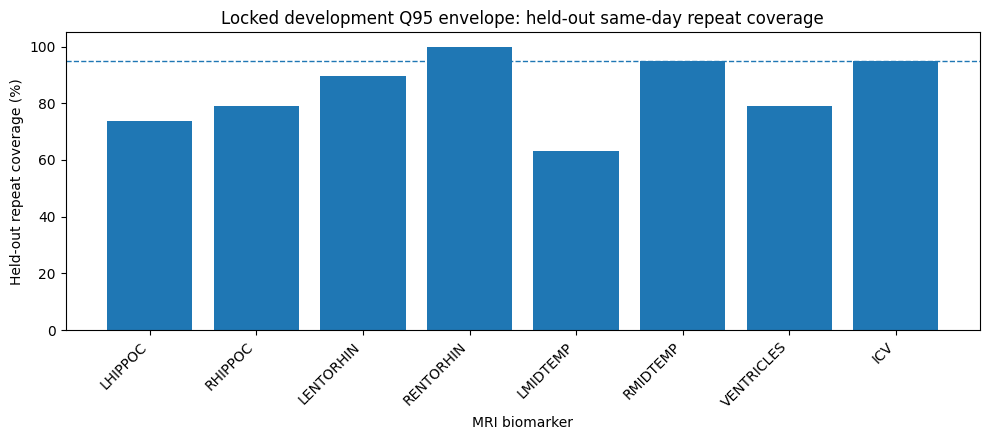

In [17]:

# Figure 1: development thresholds and held-out coverage
plot_cov = coverage.loc[coverage["threshold"] == "q95"].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plot_cov["feature"], plot_cov["heldout_coverage_pct"])
ax.axhline(95, linestyle="--", linewidth=1)
ax.set_ylim(0, 105)
ax.set_ylabel("Held-out repeat coverage (%)")
ax.set_xlabel("MRI biomarker")
ax.set_title("Locked development Q95 envelope: held-out same-day repeat coverage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_heldout_q95_coverage.png", dpi=300, bbox_inches="tight")
plt.show()


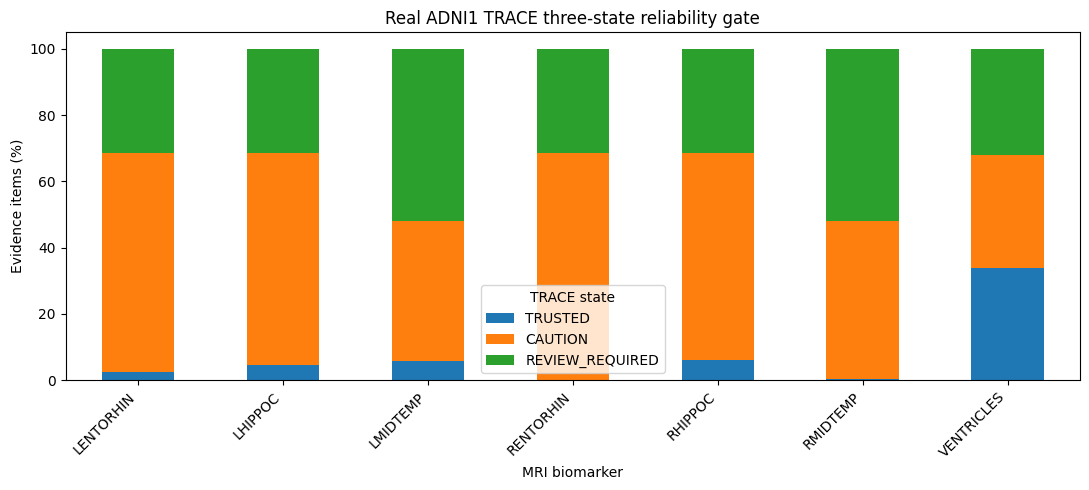

In [18]:

# Figure 2: feature-level TRACE state distribution
pivot = feature_state_summary.pivot(
    index="feature",
    columns="state",
    values="pct"
).fillna(0)

pivot = pivot.reindex(columns=["TRUSTED", "CAUTION", "REVIEW_REQUIRED"])

ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 5))
ax.set_ylabel("Evidence items (%)")
ax.set_xlabel("MRI biomarker")
ax.set_title("Real ADNI1 TRACE three-state reliability gate")
plt.xticks(rotation=45, ha="right")
plt.legend(title="TRACE state")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_feature_trace_states.png", dpi=300, bbox_inches="tight")
plt.show()


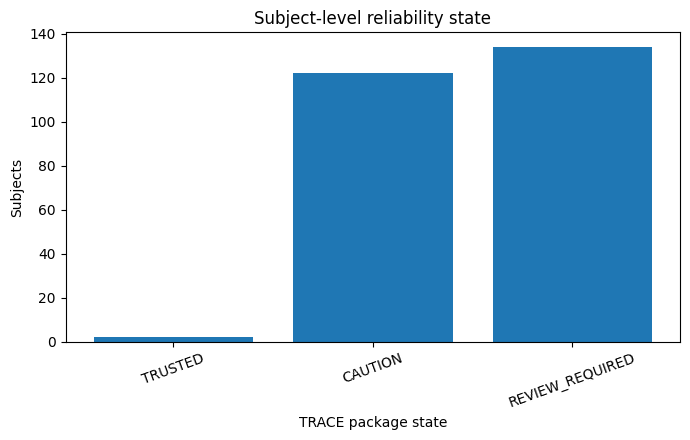

In [19]:

# Figure 3: package-state distribution
pkg = gate_df["TRACE_PACKAGE_STATE"].value_counts().reindex(
    ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(pkg.index, pkg.values)
ax.set_ylabel("Subjects")
ax.set_xlabel("TRACE package state")
ax.set_title("Subject-level reliability state")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTDIR / "figure_package_trace_states.png", dpi=300, bbox_inches="tight")
plt.show()



## 15. Aggregate exports

Only aggregate/publication-oriented tables are exported here.

The participant-level gated dataset is **not automatically exported** by this notebook to reduce the chance of accidental repository publication. If needed for Notebook 21-REAL within the same private runtime, the next cell saves it explicitly under a clearly private filename.


In [20]:

thresholds.to_csv(OUTDIR / "table_locked_technical_thresholds.csv", index=False)
coverage.to_csv(OUTDIR / "table_heldout_threshold_coverage.csv", index=False)
reproc_sensitivity.to_csv(OUTDIR / "table_reprocessing_sensitivity.csv", index=False)
feature_state_summary.to_csv(OUTDIR / "table_feature_trace_states.csv", index=False)
package_sensitivity.to_csv(OUTDIR / "table_package_rule_sensitivity.csv", index=False)
heldout_falsification.to_csv(OUTDIR / "table_heldout_falsification.csv", index=False)

# Outcome audit is aggregate only.
outcome_audit.to_csv(OUTDIR / "table_outcome_audit.csv")

print("Aggregate files written:")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)


Aggregate files written:
 - figure_feature_trace_states.png
 - figure_heldout_q95_coverage.png
 - figure_package_trace_states.png
 - table_feature_trace_states.csv
 - table_heldout_falsification.csv
 - table_heldout_threshold_coverage.csv
 - table_locked_technical_thresholds.csv
 - table_outcome_audit.csv
 - table_package_rule_sensitivity.csv
 - table_reprocessing_sensitivity.csv



## 16. Save the private participant-level gated file for Notebook 21-REAL

**Do not commit this file to GitHub.**

This file is required for the downstream A/B/C experiment.


In [21]:

PRIVATE_GATE_PATH = Path("TRACE_ADNI1_20B_REAL_GATED_PRIVATE.csv")

private_cols = [
    "RID",
    "LABEL",
    "TRACE_PACKAGE_STATE",
    "N_TRUSTED",
    "N_CAUTION",
    "N_REVIEW",
    "ICV_HARD_REVIEW",
    "OVERALL_QC_BOTH_PASS",
    "TEMP_HARD_REVIEW",
    "VENT_HARD_REVIEW",
]

for f in FEATURES:
    for c in [
        f"BL_{f}",
        f"M12_{f}",
        f"{f}_ABS_LONG_PCT",
        f"{f}_SIGNAL_TO_TECH",
    ]:
        if c in gate_df.columns:
            private_cols.append(c)

for f in BIO_FEATURES:
    private_cols.append(f"{f}_TRACE_STATE")

private_gate = gate_df[private_cols].copy()
private_gate.to_csv(PRIVATE_GATE_PATH, index=False)

print("PRIVATE participant-level file saved:")
print(PRIVATE_GATE_PATH.resolve())
print("Rows:", len(private_gate))
print("\nDO NOT PUSH THIS CSV TO GITHUB.")


PRIVATE participant-level file saved:
/content/TRACE_ADNI1_20B_REAL_GATED_PRIVATE.csv
Rows: 258

DO NOT PUSH THIS CSV TO GITHUB.


## 17. Reproducibility manifest

In [22]:

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "notebook": "20B-REAL",
    "seed": SEED,
    "inputs": {
        LONGITUDINAL_PATH.name: sha256_file(LONGITUDINAL_PATH),
        REPEAT_PATH.name: sha256_file(REPEAT_PATH),
    },
    "calibration": {
        "primary_repeat_type": ACQ_TYPE,
        "development_subjects": len(dev_rids),
        "heldout_subjects": len(heldout_rids),
        "development_pairs": len(rep_dev),
        "heldout_pairs": len(rep_heldout),
        "primary_threshold": "development Q95 absolute percent disagreement",
        "outcome_labels_used_for_calibration": False,
    },
    "longitudinal_subjects": int(gate_df["RID"].nunique()),
}

with open(OUTDIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

manifest


{'notebook': '20B-REAL',
 'seed': 2027,
 'inputs': {'TRACE_ADNI1_longitudinal_COMPLETE_REAL.csv': 'f627bd017e3287b2bad7b6894372e7c5c78bffa2e73f1c92f9d89d6274d03dea',
  'TRACE_ADNI1_repeat_pairs_REAL.csv': '3a600b5cf11df11d2511e51ebbc933eed8be3d04305b7b281271d058c37ab926'},
 'calibration': {'primary_repeat_type': 'SAME_DAY_DIFFERENT_ACQUISITION',
  'development_subjects': 42,
  'heldout_subjects': 18,
  'development_pairs': 56,
  'heldout_pairs': 19,
  'primary_threshold': 'development Q95 absolute percent disagreement',
  'outcome_labels_used_for_calibration': False},
 'longitudinal_subjects': 258}

## 18. Automated 20B-REAL readiness summary

In [23]:

print("============================================================")
print("20B-REAL READINESS SUMMARY")
print("============================================================")

print(f"Same-day repeat development pairs: {len(rep_dev)}")
print(f"Same-day repeat held-out pairs: {len(rep_heldout)}")
print(f"Longitudinal subjects gated: {gate_df['RID'].nunique()}")
print()

print("LOCKED Q95 THRESHOLDS")
display(
    thresholds[["feature", "n_dev_pairs", "q95_pct"]]
    .round(4)
)

print("\nHELD-OUT Q95 COVERAGE")
display(
    coverage.loc[
        coverage["threshold"] == "q95",
        ["feature", "n_heldout_pairs", "heldout_coverage_pct", "heldout_exceedance_pct"]
    ].round(2)
)

print("\nFEATURE-LEVEL TRACE STATES (%)")
display(
    feature_state_summary.pivot(
        index="feature",
        columns="state",
        values="pct"
    ).fillna(0).round(1)
)

print("\nPACKAGE TRACE STATES")
print(gate_df["TRACE_PACKAGE_STATE"].value_counts())
print((100 * gate_df["TRACE_PACKAGE_STATE"].value_counts(normalize=True)).round(1))

print("\nPACKAGE RULE SENSITIVITY (%)")
display(
    package_sensitivity.pivot(
        index="trusted_min_rule",
        columns="state",
        values="pct"
    ).fillna(0).round(1)
)

print("\nEXPLORATORY OUTCOME AUDIT — NOT USED FOR CALIBRATION")
display(outcome_audit)

print("\nREADINESS CHECKS")
checks = {
    "real_repeat_calibration": len(rep_dev) > 0,
    "subject_disjoint_heldout": dev_rids.isdisjoint(heldout_rids),
    "real_longitudinal_application": gate_df["RID"].nunique() > 0,
    "all_three_package_states_present": gate_df["TRACE_PACKAGE_STATE"].nunique() == 3,
    "outcome_blind_calibration": True,
}

for k, v in checks.items():
    print(f"{k}: {'PASS' if v else 'CHECK'}")

print("\nGuardrail:")
print("TRACE states quantify reliability of longitudinal imaging evidence;")
print("they do not establish diagnosis, clinical safety, or biological ground truth.")


20B-REAL READINESS SUMMARY
Same-day repeat development pairs: 56
Same-day repeat held-out pairs: 19
Longitudinal subjects gated: 258

LOCKED Q95 THRESHOLDS


,feature,n_dev_pairs,q95_pct
0,LHIPPOC,56,8.5233
1,RHIPPOC,56,7.9420
2,LENTORHIN,56,42.1863
3,RENTORHIN,56,58.3015
4,LMIDTEMP,56,8.8102
5,RMIDTEMP,56,13.1432
6,VENTRICLES,56,1.1868
7,ICV,56,0.6978



HELD-OUT Q95 COVERAGE


,feature,n_heldout_pairs,heldout_coverage_pct,heldout_exceedance_pct
1,LHIPPOC,19,73.68,26.32
4,RHIPPOC,19,78.95,21.05
7,LENTORHIN,19,89.47,10.53
10,RENTORHIN,19,100.00,0.00
13,LMIDTEMP,19,63.16,36.84
16,RMIDTEMP,19,94.74,5.26
19,VENTRICLES,19,78.95,21.05
22,ICV,19,94.74,5.26



FEATURE-LEVEL TRACE STATES (%)


...


PACKAGE TRACE STATES
TRACE_PACKAGE_STATE
REVIEW_REQUIRED    134
CAUTION            122
TRUSTED              2
Name: count, dtype: int64
TRACE_PACKAGE_STATE
REVIEW_REQUIRED    51.9
CAUTION            47.3
TRUSTED             0.8
Name: proportion, dtype: float64

PACKAGE RULE SENSITIVITY (%)


state,CAUTION,REVIEW_REQUIRED,TRUSTED
trusted_min_rule,,,
3,43.0,51.9,5.0
4,47.3,51.9,0.8
5,47.7,51.9,0.4



EXPLORATORY OUTCOME AUDIT — NOT USED FOR CALIBRATION


LABEL,pMCI,sMCI,All
TRACE_PACKAGE_STATE,,,
CAUTION,71,51,122
REVIEW_REQUIRED,67,67,134
TRUSTED,2,0,2
All,140,118,258



READINESS CHECKS
real_repeat_calibration: PASS
subject_disjoint_heldout: PASS
real_longitudinal_application: PASS
all_three_package_states_present: PASS
outcome_blind_calibration: PASS

Guardrail:
TRACE states quantify reliability of longitudinal imaging evidence;
they do not establish diagnosis, clinical safety, or biological ground truth.
